# **Notes for Colab Users**

# **Do not write directly in this file—your work may disappear!**

# **Always make a copy before you start.**

How to make a copy

1. Click “File” in the top left.  
> *If you can’t see menus like “File” or “Runtime,” click the “v” icon in the top right to show them.*

2. Select “Save a copy in Drive”  

3. Rename the copied file to “YOURNAMEs_FileName.ipynb”  
> Example: if your name is Olivia → Olivias_FileName.ipynb  


---

* Check marks (✅) are not saved. If you refresh the page with Chrome’s reload button, they will disappear.<br>  
If you need to stop in the middle, add a text cell and write something like “SO FAR DONE”.

---

* In Colab, **previous output results are reset every 30 to 90 minutes**.<br>  
Because of that, errors like `~~ is not defined` **happen very often**.

🔁 What should you do if you get a `~~ is not defined` error?

1. First, check the spelling of the variable name.<br>  
2. If the spelling is correct but you still get the error, **click that cell to select it**.<br>  
3. Click “Runtime” → “Run before” in the top left.<br>  
→ This will **rerun all cells before it**.  
4. Then run that cell again.

If the error still does not go away,<br>  
there may be a basic mistake in your TODO: answer in an earlier cell.<br>  
Check whether it is correct.<br>  
Or ask ChatGPT or another coding assistant for help.

# **Preparation**

In this section, we’ll just load the content from the previous Chapter.<br>
You only need to run the code.<br>
You don’t need to read it.<br>
Feel free to move on.<br>

In [ ]:
# Please download the file.
!wget https://raw.githubusercontent.com/HayatoHongo/Colab_GPT/main/input.txt -O input.txt
# Load the input.text file downloaded in UTF-8.
with open("input.txt", 'r', encoding = 'utf-8') as f:
    text = f.read()

# A function to display tensors more clearly (optional)
import torch
import torch.nn as nn
import torch.nn.functional as F

# Install a library to display tensors more clearly
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# Import a function to display PyTorch tensors clearly
from torch_print_tensor import print_formatted_tensor


--2025-11-08 10:53:36--  https://raw.githubusercontent.com/HayatoHongo/Colab_GPT/main/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.007s  

2025-11-08 10:53:36 (153 MB/s) - ‘input.txt’ saved [1115394/1115394]



# **Chapter 16: Just Make the Model Bigger**


### **Section 1: Improving the `Trainer` class**

Google Colab gives you a free T4 GPU. Let’s use it.

In [ ]:
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'  # Device to use (GPU or CPU)
print(device_type)

cuda


**`Check Point`**  
<label><input type="checkbox">I confirmed that the runtime is set to cuda (GPU)<br></label>

#### Let’s scale up the model and break through the loss plateau

Last time, we trained a **very small model** with about 200,000 parameters on a **small Shakespeare dataset** (`input.txt`) with about 100,000 characters.

But no matter how much compute we threw at it, the **validation error val loss got stuck around 1.7 to 1.8**.

When the loss stops going down like this, it is called a **loss plateau**.

So this time, we will spend our compute on **making the model larger**.

In general, **larger models with more parameters have higher expressive power, so we can expect the loss plateau to drop to a lower level**.


#### Visualizing Training Time and Processed Tokens

This training run takes **about 50 minutes**.
As training moves forward, the **total number of tokens processed by the model** keeps growing too.

So, to make the training progress easier to follow,
we now record the following information at each step.

* `total_seen_tokens`, which shows the **total number of tokens used in training** up to that point
* `total_train_time`, which shows the **cumulative training time in seconds** up to that point

To store these values, we added matching variables and lists to the `Trainer` class.


🔘 **Options**: There may be extra choices. You might use the same choice more than once.

`[]`　`()`

In [ ]:
# TODOFILL
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        # ######### NEW ##########
        # A list that records the number of tokens processed so far during training
        self.total_seen_tokens_list = __  # TODO: FILL
        # A list for recording the total training time
        self.total_train_time_list = __ # TODO: FILL
        # ######### NEW ##########

    def train_step(self):
        # Get a batch for training.
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # Model forward pass and loss calculation
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # Backpropagation
        self.optimizer.step()  # Parameter update

        return loss.item() # Return the loss value

    def evaluate(self):
        self.model.eval()  # Switch to evaluation mode
        losses = {"train": [], "val": []} # Compute the loss for both the training and validation data
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # Switch back to training mode

        # Compute and return the average loss for each dataset (train, val)
        return {split: sum(values) / len(values) for split, values in losses.items()}

'\nimport time\n\nclass Trainer:\n    def __init__(self, model, optimizer, data_loader, config):\n        self.model = model\n        self.optimizer = optimizer\n        self.data_loader = data_loader\n        self.config = config\n\n        self.steps = []\n        self.train_losses = []\n        self.val_losses = []\n        ########## NEW ##########\n        # 学習過程で「これまでに処理したトークン数」を記録するリスト\n        self.total_seen_tokens_list = __  # TODO: FILL\n        # 学習にかかった累計時間を記録するリスト\n        self.total_train_time_list = __ # TODO: FILL\n        ########## NEW ##########\n\n    def train_step(self):\n        # トレーニング用バッチを取得。\n        input_batch, target_batch = self.data_loader.get_batch(\'train\')\n        self.optimizer.zero_grad()\n\n        # モデルの順伝播と損失計算\n        logits, loss = self.model(input_batch, target_batch)\n        loss.backward()  # 誤差逆伝播\n        self.optimizer.step()  # パラメータ更新\n\n        return loss.item() # 損失の値を返す\n\n    def evaluate(self):\n        self.model.eval()  # 評

In [ ]:
# ANSWERFILLED
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        # ######### NEW ##########
        self.total_seen_tokens_list = []
        self.total_train_time_list = []
        # ######### NEW ##########

    def train_step(self):
        # Get a batch for training.
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # Forward pass and loss calculation
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # Backpropagation
        self.optimizer.step()  # Parameter update

        return loss.item() # Return the loss value

    def evaluate(self):
        self.model.eval()  # Switch to evaluation mode
        losses = {"train": [], "val": []} # Calculate the loss for both the training and validation data
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # Switch back to training mode

        # Calculate and return the average loss for each dataset (train, val).
        return {split: sum(values) / len(values) for split, values in losses.items()}

<details>
<summary>Click to show/hide the answer</summary>

```python
# ANSWERFILLED
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        ########## NEW ##########
        self.total_seen_tokens_list = []
        self.total_train_time_list = []
        ########## NEW ##########

    def train_step(self):
        # Get a batch for training.
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # Forward pass through the model and compute the loss
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # Backpropagation
        self.optimizer.step()  # Update parameters

        return loss.item() # Return the loss value

    def evaluate(self):
        self.model.eval()  # Switch to evaluation mode
        losses = {"train": [], "val": []} # Compute losses for both training and validation data
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # Switch back to training mode

        # Compute and return the average loss for each dataset (train, val)
        return {split: sum(values) / len(values) for split, values in losses.items()}
```

🔘 **Options**: There may be extra choices. You might use the same choice more than once.

`1`　`0`　`interval_from_last_eval`　`last_eval_end_time`　`self.config.batch_size`　`step`　`append`　`logits`　`self.config.total_training_steps`　`evaluation_interval`

In [ ]:
# TODOFILL
# Continuation of the Trainer class
def train(self):
    # Run train_step the number of times specified in the config.
    for step in range(self.config.total_training_steps):
        # Evaluate every 100 iterations, or only at the final step.
        if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:
            # Exclude step==0 because last_eval_end_time is undefined. Exclude the final step because it may be measured mid-run.
            if step == 0 or step == self.config.total_training_steps - 1:
              tokens_per_second = None
              # ######### NEW ##########
              if step == 0:
                # Since no time has elapsed in the first step yet, initialize the accumulated time.
                total_train_time = __ # TODO: FILL
              else: # step == self.config.total_training_steps - 1
                # In the final step, add the elapsed time since the last evaluation.
                current_time = time.time()
                interval_from_last_eval = current_time - _____________ # TODO: FILL
                total_train_time += ______________ # TODO: FILL
              # ######### NEW ##########
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              # ######### NEW ##########
              # Add the elapsed time between evaluations to the total training time
              total_train_time += _____________ # TODO: FILL
              # ######### NEW ##########
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

            eval_loss = self.evaluate()

            # ######### NEW ##########
            # Calculate the number of tokens processed so far
            total_seen_tokens = ________________ * self.config.input_sequence_length * _____ # TODO: FILL
            # ######### NEW ##########

            # ######### NEW ##########
            # Print step, loss, processing speed (tok/s), token count, and elapsed time together.
            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )
            # ######### NEW ##########

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])

            # ######### NEW ##########
            # Add the total token count and elapsed time to the log list
            self.total_seen_tokens_list.______(total_seen_tokens) # TODO: FILL
            self.total_train_time_list.append(total_train_time)
            # ######### NEW ##########

            # Record the time when this evaluation finished. The time difference from the start of the next evaluation becomes `evaluation_interval`.
            last_eval_end_time = time.time()

        # One training step (the main process performed each time)
        train_loss = self.train_step()  

'\ndef train(self):\n    # configで指定された回数だけtrain_stepを実行する。\n    for step in range(self.config.total_training_steps):\n        # 100回ごと、または最終ステップのみ評価する。\n        if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:\n            # step==0 は last_eval_end_time 未定義のため除外。最終ステップは途中計測になる可能性があるため除外。\n            if step == 0 or step == self.config.total_training_steps - 1:\n              tokens_per_second = None\n              ########## NEW ##########\n              if step == 0:\n                # 最初のステップではまだ経過時間がないため、累計時間を初期化する。\n                total_train_time = __ # TODO: FILL\n              else: # step == self.config.total_training_steps - 1\n                # 最終ステップでは最後の評価からの経過時間を加算\n                current_time = time.time()\n                interval_from_last_eval = current_time - _____________ # TODO: FILL\n                total_train_time += ______________ # TODO: FILL\n              ########## NEW ##########\n            else:\n       

In [ ]:
# ANSWERFILLED
# Continuation of the Trainer class
def train(self):
    # Run train_step the number of times specified in the config.
    for step in range(self.config.total_training_steps):

        # Evaluate every 100 iterations, or only at the final step.
        if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:
            # Exclude step==0 because last_eval_end_time is undefined. Exclude the final step because it may be a partial measurement.
            if step == 0 or step == self.config.total_training_steps - 1:
              tokens_per_second = None
              # ######### NEW ##########
              # First step
              if step == 0:
                total_train_time = 0
              # Final step
              else:
                current_time = time.time()
                interval_from_last_eval = current_time - last_eval_end_time
                total_train_time += interval_from_last_eval
              # ######### NEW ##########
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              # ######### NEW ##########
              total_train_time += evaluation_interval
              # ######### NEW ##########
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

            eval_loss = self.evaluate()

            # ######### NEW ##########
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            # ######### NEW ##########

            # ######### NEW ##########
            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )
            # ######### NEW ##########

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            # ######### NEW ##########
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)
            # ######### NEW ##########

            # Record the time when this evaluation finishes. The time difference from the start of the next evaluation becomes `evaluation_interval`.
            last_eval_end_time = time.time()

        # One training step (the main processing done each time)
        train_loss = self.train_step()

<details>
<summary>Click to show/hide the answer</summary>

```python
# ANSWERFILLED
def train(self):
    # Run train_step the number of times set in config.
    for step in range(self.config.total_training_steps):

        # Evaluate every 100 steps, or only at the final step.
        if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:
            # Exclude step==0 because last_eval_end_time is not defined yet.
            # Exclude the final step because it may be measured mid-interval.
            if step == 0 or step == self.config.total_training_steps - 1:
              tokens_per_second = None
              ########## NEW ##########
              # First step
              if step == 0:
                total_train_time = 0
              # Final step
              else:
                current_time = time.time()
                interval_from_last_eval = current_time - last_eval_end_time
                total_train_time += interval_from_last_eval
              ########## NEW ##########
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              ########## NEW ##########
              total_train_time += evaluation_interval
              ########## NEW ##########
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

            eval_loss = self.evaluate()

            ########## NEW ##########
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            ########## NEW ##########

            ########## NEW ##########
            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )
            ########## NEW ##########

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            ########## NEW ##########
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)
            ########## NEW ##########

            # Record when this evaluation finished.
            # The time gap until the next evaluation starts becomes `evaluation_interval`.
            last_eval_end_time = time.time()

        # One training step. This is the main work that runs every time.
        train_loss = self.train_step()
```

🔧 The Official Pattern for Adding or Replacing a Class method

```python
def new_function(self, ...):
    ...

existing_class.method_name = new_function
```

In [ ]:
Trainer.train = train

The `train` function has gotten long, and all the `if` statements make it hard to read.
So we’ll refactor it to improve readability.

More specifically, we’ll line up the **final step** and the **evaluation step** so we need fewer condition branches.

Right now, the loop looks like this:

```python
for step in range(self.config.total_training_steps):
```

So `step` goes from `0` to `total_training_steps - 1`.
For example, if `total_training_steps = 1000` and `evaluation_frequency = 100`, the last `step` is `999`, which does not match the evaluation timing multiples of 100.

---

So instead, we increase the total number of steps by just one, like this:

```python
for step in range(self.config.total_training_steps + 1):
```

Now the final step is also included in evaluation.
That makes the code simpler.

If `total_training_steps` is not a multiple of `evaluation_frequency` for example, 1050 and 100, this approach will not work, but in practice that is usually not a problem.


🔘 **Options**: There may be extra choices. You might use the same choice more than once.

`self.config.total_training_steps`　`self.config.total_training_steps+1`　`1`　`0`

In [ ]:
# TODOFILL
def new_train(self):
    # Run train_step the number of times specified in the config + 1.)
    # ######### NEW ##########
    for step in range(____________________________): # TODO: FILL
    # ######### NEW ##########
        # Evaluate every 100 times.
        # ######### NEW ##########
        if step % self.config.evaluation_frequency == 0:
        # ######### NEW ##########

            # ######### NEW ##########
            # First step
            if step == __:  # TOOD: FILL
              tokens_per_second = None
              total_train_time = 0
            # ######### NEW ##########

            # Evaluation steps from the second time onward (including the final step)
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              total_train_time += evaluation_interval
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

            eval_loss = self.evaluate()
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            # Record the time when this evaluation ends. The time difference from the start of the next evaluation becomes `evaluation_interval`.
            last_eval_end_time = time.time()

        # One training step (main processing performed each time)
        train_loss = self.train_step()


In [ ]:
# ANSWERFILLED
def new_train(self):
    # Run train_step (the number of times specified in config + 1).
    # ######### NEW ##########
    for step in range(self.config.total_training_steps+1): # TODO: FILL
    # ######### NEW ##########
        # Evaluate every 100 iterations.
        # ######### NEW ##########
        if step % self.config.evaluation_frequency == 0:
        # ######### NEW ##########

            # ######### NEW ##########
            # First step
            if step == 0:  # TOOD: FILL
              tokens_per_second = None
              total_train_time = 0
            # ######### NEW ##########

            # Evaluation steps from the second run onward (including the final step)
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              total_train_time += evaluation_interval
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

            eval_loss = self.evaluate()
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            # Record the time when this evaluation finishes. The time difference from the start of the next evaluation becomes `evaluation_interval`.
            last_eval_end_time = time.time()

        # One training step (the main processing performed each time)
        train_loss = self.train_step()

<details>
<summary>Click to show/hide the answer</summary>

```python
# ANSWERFILLED
def new_train(self):
    # Run train_step for the number of times set in config, plus 1.
    ########## NEW ##########
    for step in range(self.config.total_training_steps+1): # TODO: FILL
    ########## NEW ##########
        # Evaluate every 100 steps.
        ########## NEW ##########
        if step % self.config.evaluation_frequency == 0:
        ########## NEW ##########

            ########## NEW ##########
            # The first step
            if step == 0:  # TOOD: FILL
              tokens_per_second = None
              total_train_time = 0
            ########## NEW ##########

            # Evaluation steps from the second time onward including the final step
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              total_train_time += evaluation_interval
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

            eval_loss = self.evaluate()
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

            print(
                f"step {step:05d} | "
                f"train loss {eval_loss['train']:.4f} | "
                f"val loss {eval_loss['val']:.4f} | "
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                f"tokens {total_seen_tokens:,} | "
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.train_losses.append(eval_loss['train'])
            self.val_losses.append(eval_loss['val'])
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            # Record the time when this evaluation finished.
            # The time gap until the next evaluation starts becomes `evaluation_interval`.
            last_eval_end_time = time.time()

        # One training step the main process that runs every time
        train_loss = self.train_step()
  ```

🔧 The Official Pattern for Adding or Replacing a Class method

```python
def new_function(self, ...):
    ...

ExistingClass.method_name = new_function
```

* **The method name stays the same** (`train()` still works)
* **Only the inside gets replaced** (`new_train` runs instead)
<br>

In [ ]:
Trainer.train = new_train # TODO: Hint: Don't overthink it. It's very simple.

**Section 1: Improving the `Trainer` Class** <label><input type="checkbox"> Mark as Done</label>

### **Section 2: Overfitting in LLMs**

Define the `Dataloader` class and the model class. They are exactly the same as in Chapter 12.

In [ ]:
class DataLoader:
    def __init__(self, text, config):
        self.config = config  # Configuration object
        chars = sorted(list(set(text)))  # Sort unique characters
        self.ctoi = {char: index for index, char in enumerate(chars)}
        self.itoc = {index: char for index, char in enumerate(chars)}
        self.vocab_size = len(chars)

        # Encode it and convert it to a tensor.
        # You need `self.` to call methods or access arguments outside of `__init__`.
        self.data = torch.tensor(self.encode(text), dtype=torch.long)

        # Split into training and validation sets.
        # self.data is used even if no arguments are specified.
        self.train_data, self.val_data = self.split_data()

    def encode(self, text):
        # Converts a string into a sequence of indices. Uses self. to call other methods and arguments.
        return [self.ctoi[c] for c in text]

    def decode(self, indices):
        return ''.join([self.itoc[i] for i in indices])

    def split_data(self):
        split_index = int(0.9 * len(self.data))  # Point to split 90% of the data for training.
        return self.data[:split_index], self.data[split_index:]

    def get_batch(self, split):
        data = self.train_data if split == 'train' else self.val_data
        start_indices = torch.randint(len(data) - self.config.input_sequence_length, (self.config.batch_size,)) # Generate the extraction start index

        input_sequences = torch.stack([
            data[start_index:start_index + self.config.input_sequence_length]
            for start_index in start_indices
        ])
        target_sequences = torch.stack([
            data[start_index + 1:start_index + self.config.input_sequence_length + 1]
            for start_index in start_indices
        ])
        return input_sequences.to(self.config.device_type), target_sequences.to(self.config.device_type)

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # Define an embedding table of vocabulary size x embedding dimension
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # Retrieve the embedding vector corresponding to the input index
        return self.token_embedding_table.forward(input_indices)

class PositionEmbedding(nn.Module):
    def __init__(self, input_sequence_length = 8, embedding_dim = 8):
        super().__init__()
        # Positional embedding layer
        self.position_embedding_layer = nn.Embedding(input_sequence_length, embedding_dim)

    def forward(self, input_indices):
        # Shape of the input tensor input_indices: [batch size, sequence length].
        sequence_length = input_indices.shape[1]

        # Create position indices based on the sequence length (for example: [0, 1, 2, ..., sequence_length-1])
        position_indices = torch.arange(sequence_length, device=input_indices.device)

        # Get the embedding vector for the position index
        position_embeddings = self.position_embedding_layer.forward(position_indices)

        return position_embeddings

class EmbeddingModule(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # Embedding layer for each token
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)  # Word embedding layer
        self.position_embedding_layer = PositionEmbedding(input_sequence_length = config.input_sequence_length, embedding_dim = config.embedding_dim)  # Embed location information

    def forward(self, input_indices):
        # Get token embeddings
        token_embeddings = self.token_embedding_layer.embed(input_indices)

        # Get the positional embedding
        position_embeddings = self.position_embedding_layer.forward(input_indices)

        # Add token embeddings and positional embeddings
        embeddings = position_embeddings + token_embeddings
        return embeddings


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # dropout
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # Batch, token length, embedding channels

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Calculating attention scores (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # Mask applied
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # Softmax → Dropout → Weighted sum
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # Manage multiple heads with ModuleList
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # Linear layer that mixes the outputs of each head
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # Output dropout
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # Get the output of each head
        # List of (B, T, head_size)
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # Concatenate the outputs of all heads → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # Output mixing in linear transformation
        projected = self.output_projection.forward(concatenated)

        # Apply dropout to the final output
        output = self.dropout.forward(projected)

        return output


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)


class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # Each LayerNorm keeps its own beta and gamma.
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # The forward method is omitted.
        normed_input = self.layer_norm1(input_tensor) # Apply layer normalization to the input
        attention_output = self.multihead_attention(normed_input) # Apply multi-head attention
        residual_attention = attention_output + input_tensor # Add "before! layernorm1"
        normed_attention = self.layer_norm2(residual_attention) # Apply LayerNorm again to the residual output
        feedforward_output = self.feed_forward(normed_attention) # Apply the feedforward network
        final_output = feedforward_output + residual_attention # Add the "before" layernorm2!

        return final_output


class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # Layer normalization
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # Vocabulary size projection
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Apply layer normalization to the output of the Transformer block.
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # Use a linear layer to convert the scores into the vocabulary dimension.
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits


class nanoGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # Keep this because it is also used during generation.
        self.embedding = EmbeddingModule(vocab_size, config=config)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # Generate text
    def generate(self, input_indices, max_new_tokens):
        # Generate only the specified number of tokens, max_new_tokens
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # Crop the input

            # The forward pass returns `(likelihood, loss)`—keep only `likelihood` as `logits`.
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # Extract the logits of the last token
            probs = F.softmax(last_logits, dim=-1) # Convert likelihoods to probabilities with Softmax

            # Sample the next token
            next_token = torch.multinomial(probs, num_samples=1)

            # Integrate the new tokens and update input_indices.
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # Return the final `input_indices`. Its length is the original `input_indices` + `max_new_tokens`
        return input_indices

    # Compute likelihood and loss
    def forward(self, input_indices, target_indices):
        embeddings = self.embedding(input_indices)
        blocks_output = self.blocks(embeddings)
        logits = self.vocab_projection(blocks_output)

        # During inference, there is no target, so loss is None.
        # —Only probabilities (logits) are returned.
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

#### 🦖 Dramatically Scale Up the Model Size

In this tutorial, **we’re cranking up the scale of the model all at once.**

| Parameter | Before | After | Scale | What it means |
| ----------------------- | --- | -------- | -- | ---------------------------- |
| Embedding dimension (`embedding_dim`) | 64  | **512**  | ×8 | Represents tokens in a much higher-dimensional space, which boosts expressive power |
| Hidden dimension (`hidden_dim`)      | 256 | **2048** | ×8 | Set to 4 times the embedding size, which expands the model’s internal processing capacity |


Also, we set the dimension of each head to 64, so since 512 ÷ 64 = 8, the number of attention heads is 8.


In [ ]:
# A configuration class for saving model settings
class ModelConfig:
    batch_size = 16
    input_sequence_length = 512  # To reduce the proportion of time spent on data loading, fetch longer sequences at once.
    total_training_steps = 10_000  # It takes about 1 minute.
    device_type = 'cuda'  # Fix the device to GPU
    evaluation_frequency = 100  # Model performance evaluation frequency
    learning_rate = 0.001  # Learning rate
    evaluation_loops = 10  # Number of evaluation iterations
    # ######### NEW ##########
    embedding_dim = 512  # Embedding layer size (feature vector dimension)
    hidden_dim = 2048
    num_attention_heads = 8  # Number of attention heads
    # ######### NEW ##########
    layer_count = 4  # Number of model layers
    dropout_rate = 0.1  # Dropout probability
    random_seed_value = 1337  # Random seed for reproducibility

In [ ]:
# Load the settings and set the seed
config = ModelConfig()
torch.manual_seed(config.random_seed_value)  # Set a random seed to ensure reproducibility

In [ ]:
# Load data
with open("input.txt", 'r', encoding = 'utf-8') as f:
    text_data = f.read()
data_loader = DataLoader(text_data, config)

In [ ]:
# Initialize the model and optimizer
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

The total number of parameters in the whole model jumped from about 0.24M to 12.9M,
a huge increase of **about 50x**.

| Metric | Before | After | Increase |
| ------ | ------ | ---------- | -------- |
| Number of parameters | About 0.24M | **About 12.9M** | **About 50x** |

By expanding the embeddings and hidden layers,
the model can now hold and learn more information internally.


In [ ]:
# Display the number of model parameters.
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

12.933185 M parameters


### 🚀 Let’s Start Training!

Now it’s finally time to start training.
Since the model is bigger, **the compute cost per step is also higher**.

This time, we’ll use a **15 GB RAM T4 GPU**,
with `batch size = 16` and `total steps = 10,000`.

With these settings, **training will take about 50 minutes** to finish 😇

If you’re using an A100 40GB RAM, expect it to take around 15~20 minutes.

Honestly, it’s a pretty long wait... go have some fun.

If you want, Watch the video! 👇 (it’s only 3 minutes)

🎬 [I built ChatGPT with Minecraft redstone!](https://youtu.be/VaeI9YgE1o8?si=8nQ4fQaSx6HP4iWF)

In [ ]:
print("===Training started successfully===")

# Train the model
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

===トレーニングが正常に開始されました===
step 00000 | train loss 4.3219 | val loss 4.3275 | tok/s None | tokens 0 | time 0.00s
step 00100 | train loss 2.4815 | val loss 2.5023 | tok/s 28593 | tokens 819,200 | time 28.65s
step 00200 | train loss 2.4664 | val loss 2.4969 | tok/s 28325 | tokens 1,638,400 | time 57.57s
step 00300 | train loss 2.4401 | val loss 2.4825 | tok/s 27345 | tokens 2,457,600 | time 87.53s
step 00400 | train loss 2.4280 | val loss 2.4774 | tok/s 27396 | tokens 3,276,800 | time 117.43s
step 00500 | train loss 2.3833 | val loss 2.4609 | tok/s 26759 | tokens 4,096,000 | time 148.04s
step 00600 | train loss 2.3184 | val loss 2.3672 | tok/s 27065 | tokens 4,915,200 | time 178.31s
step 00700 | train loss 2.1886 | val loss 2.2633 | tok/s 27041 | tokens 5,734,400 | time 208.61s


KeyboardInterrupt: 

Let’s plot it with `matplotlib`, using `Step` on the horizontal axis and `Loss` on the vertical axis.

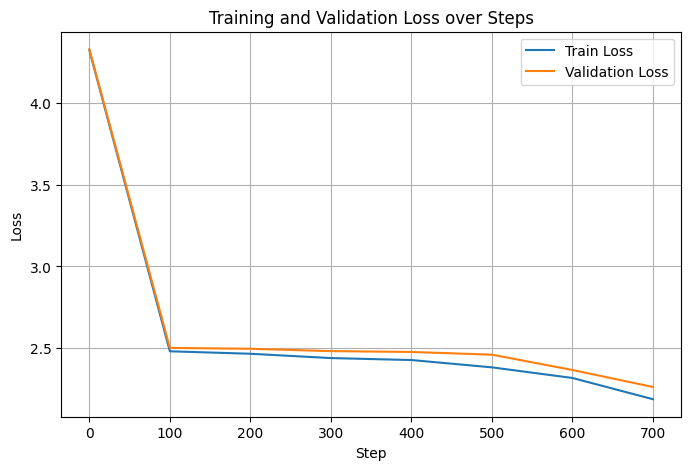

In [ ]:
# Plot the graph.
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')
plt.plot(trainer.steps, trainer.val_losses, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

#### The loss plateau dropped, but signs of overfitting showed up too

In this training run, the validation loss dropped to about 1.5!

Compared with the last time, when it was around 1.7 to 1.8, you can clearly see that the loss plateau shifted lower.

...But if you look closely, in the second half of training, **the validation loss actually starts to rise**, and **the gap from the training loss keeps getting wider**.

---

This is a textbook pattern of **overfitting**.

---

If we keep training like this, the training loss will get closer and closer to almost 0, and the model will end up reproducing the training data almost exactly.

In other words, it becomes a state where it has “memorized every last word.” Pretty impressive in its own way, honestly lol

<br>

The Shakespeare dataset we are using here is still very small, with only about 100,000 characters ($\approx$ around 100,000 tokens).

On the other hand, we massively increased the number of model parameters from about 240,000 to about 12 million, which is about 50 times larger.

This imbalance is why **the model is starting to “memorize too much” of the data**.
Also, the total number of tokens processed during all of training (`total_seen_tokens`) reaches **about 80 million tokens**.
But there are only about 100,000 possible starting positions for sampling, so even if the samples are chosen randomly,

it means **the exact same sentences are being sampled hundreds of times over**.


In [ ]:
# Let's try inference too.
# Switch to evaluation mode. Disable dropout.
model.eval()
print("Model set to eval mode")

Model set to eval mode


In [ ]:
prompt = "Let's he"
print(f"\n入力プロンプト: {prompt}")

# Tokenize and convert to tensors
encoded = data_loader.encode(prompt) # Encode text into an ID
print("encoded", encoded)
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # Convert the list of IDs into tensor format
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.unsqueeze(0)  # Add batch dimension
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.to(config.device_type) # Transfer encoded_tensor to cuda (GPU)
print_formatted_tensor(encoded_tensor)


入力プロンプト: Let's he
encoded [24, 43, 58, 5, 57, 1, 46, 43]
Tensor Size: [8]
tensor([
         24.00,  43.00,  58.00,   5.00,  57.00,   1.00,  46.00,  43.00
       ])
Tensor Size: [1, 8]
tensor([
         [ 24.00,  43.00,  58.00,   5.00,  57.00,   1.00,  46.00,  43.00]
       ])
Tensor Size: [1, 8]
tensor([
         [ 24.00,  43.00,  58.00,   5.00,  57.00,   1.00,  46.00,  43.00]
       ])


In [ ]:
# Text generation
generated_text = model.generate(encoded_tensor, max_new_tokens=512)

In [ ]:
decoded_text = data_loader.decode(generated_text[0].tolist())
print(decoded_text)

Let's here he unterothes themy thy ar gn
Whall vignts fres theever conthe groumand amay, afften: now sh sher trintrock, soufthus
a dattichem ilichisland'd ckinsinshavescongse seet wor ath anso you. Yen pe yown


Cimetizect MANENou th his toour, gaike,
And's rmivess wecowe, s, m'st red kis to,
And,
The in Kit ses upood cheing, this de?
ING VIVIVICARET:
keade h nd! athow! Ju, to ine Yor, st chat inds y f gl frethan ay theaiga h ameamanthally hecrd?

Ser ustodley las ix his
amsentat ago s k ard f ds
'd beshapt ORK:
By


The spelling is almost perfect. Since it’s an overfitted model, though, the output lacks variety.

**Section 2: Overfitting in LLMs** <label><input type="checkbox"> Mark as Done</label>

### **Section 3: Saving to Google Drive**

This time, we’re training with plenty of T4 GPU power, so let’s make sure to save the training logs properly.

Google Drive is the easiest pick.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Collect logs from the trained trainer
results = {
    "step": trainer.steps,
    "train_loss": trainer.train_losses,
    "val_loss": trainer.val_losses,
    "total_seen_tokens": trainer.total_seen_tokens_list,
    "total_train_time": trainer.total_train_time_list,
}

print(results)

{'step': [0, 100, 200, 300, 400, 500, 600, 700], 'train_loss': [4.3219249725341795, 2.481521201133728, 2.4664280652999877, 2.4400654077529906, 2.4280304193496702, 2.3833382606506346, 2.3183768033981322, 2.1885696172714235], 'val_loss': [4.327525091171265, 2.502288293838501, 2.496890687942505, 2.4824543237686156, 2.477354907989502, 2.46087167263031, 2.367189908027649, 2.2633102416992186], 'total_seen_tokens': [0, 819200, 1638400, 2457600, 3276800, 4096000, 4915200, 5734400], 'total_train_time': [0, 28.650230884552002, 57.571067333221436, 87.5279221534729, 117.42910671234131, 148.04282689094543, 178.31046843528748, 208.60511946678162]}


```python
Function: pd.DataFrame
Arguments: results (a data structure such as a dictionary or list)
```


In [ ]:
import pandas as pd
# Convert to a pandas DataFrame
df = pd.DataFrame(results) # TODO: function (argument)

In [ ]:
df

,step,train_loss,val_loss,total_seen_tokens,total_train_time
0,0,4.321925,4.327525,0,0.000000
1,100,2.481521,2.502288,819200,28.650231
2,200,2.466428,2.496891,1638400,57.571067
3,300,2.440065,2.482454,2457600,87.527922
4,400,2.428030,2.477355,3276800,117.429107
5,500,2.383338,2.460872,4096000,148.042827
6,600,2.318377,2.367190,4915200,178.310468
7,700,2.188570,2.263310,5734400,208.605119


```python
function: os.makedirs
arguments: dir_path, exist_ok=True
```

* `os.makedirs(dir_path)` creates a directory at the path you specify.
* If you set `exist_ok=True`, it will safely skip the step without raising an error, even if the folder already exists.


In [ ]:
# Create the destination folder.
import os
dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter16" # TODO: function(arguments)
os.makedirs(dir_path, exist_ok=True)

In [ ]:
# Specify the path where the file will be saved as a CSV file.
save_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter16/training_logs.csv"

```python
instance: df (a pandas DataFrame)
method: to_csv
arguments: save_path, index=False
```

* `df.to_csv(save_path, index=False)` saves the contents of `df` as a CSV file.
* When you set `index=False`, the DataFrame’s row numbers (the index) are not written to the CSV.

In [ ]:
# Save as CSV
df.to_csv(save_path, index=False) # TODO: instance.method(argument)
print(f"✅ CSV saved to: {save_path}")

✅ CSV saved to: /content/drive/MyDrive/nanoGPT_logs/Chapter16/training_logs.csv


#### 📂 How to Check the Log Files

Open [Google Drive](https://drive.google.com/drive/u/0/home) and check there.

Inside the folder you created, **`nanoGPT_logs/Chapter16`**,
you should see log files saved in CSV format.

---

⚠️ **Note:**
If you keep going without successfully mounting Google Drive,
the folders and files will be saved in a folder named `drive` in **Colab’s local environment**. They will not be on Google Drive.

If that happens, mount Drive again.

---


**`Check Point`** <label><input type="checkbox">I checked the CSV file on Google Drive<label>

Next, let’s also save the `config` instance, which stores the model details, as `config.json`.

```python
function: vars
arguments: config.__class__
```

* `vars(config.__class__)` gets the attributes of the class of the `config` instance (`config.__class__`) as a dictionary.
* `vars` is the recommended built-in function for accessing `__dict__`.
* As a result, you get a dictionary in the form `{attribute_name: attribute_value, ...}`.

In [ ]:
# Convert class attributes to a dictionary
config_class_dict = vars(config.__class__) # TODO: function(arguments)
print(config_class_dict)

{'__module__': '__main__', 'batch_size': 16, 'input_sequence_length': 512, 'total_training_steps': 10000, 'device_type': 'cuda', 'evaluation_frequency': 100, 'learning_rate': 0.001, 'evaluation_loops': 10, 'embedding_dim': 512, 'hidden_dim': 2048, 'num_attention_heads': 8, 'layer_count': 4, 'dropout_rate': 0.1, 'random_seed_value': 1337, '__dict__': <attribute '__dict__' of 'ModelConfig' objects>, '__weakref__': <attribute '__weakref__' of 'ModelConfig' objects>, '__doc__': None}


```python
original varaible: config_class_dict
method: items
arguments: none

new varaible = original varaible.method(arguments)
```

* Using `.items()` turns it into a format where you can process each class attribute name key and its value one by one.


In [ ]:
# Get the dictionary's (key, value) pairs
config_dict_items = config_class_dict.items() # TODO: new_variable = original_variable.method(argument)
print(config_dict_items)

dict_items([('__module__', '__main__'), ('batch_size', 16), ('input_sequence_length', 512), ('total_training_steps', 10000), ('device_type', 'cuda'), ('evaluation_frequency', 100), ('learning_rate', 0.001), ('evaluation_loops', 10), ('embedding_dim', 512), ('hidden_dim', 2048), ('num_attention_heads', 8), ('layer_count', 4), ('dropout_rate', 0.1), ('random_seed_value', 1337), ('__dict__', <attribute '__dict__' of 'ModelConfig' objects>), ('__weakref__', <attribute '__weakref__' of 'ModelConfig' objects>), ('__doc__', None)])


Because the extra key `__module__` is mixed in, let’s remove it.

Writing it all from scratch is a pain, so you can just type it out.

```python
config_dict = {
    key: value
    for key, value in config_dict_items
    if not key.startswith("__")
}
```

In [ ]:
config_dict = {
    key: value
    for key, value in config_dict_items
    if not key.startswith("__")
} # TODO: 

print(config_dict)

{'batch_size': 16, 'input_sequence_length': 512, 'total_training_steps': 10000, 'device_type': 'cuda', 'evaluation_frequency': 100, 'learning_rate': 0.001, 'evaluation_loops': 10, 'embedding_dim': 512, 'hidden_dim': 2048, 'num_attention_heads': 8, 'layer_count': 4, 'dropout_rate': 0.1, 'random_seed_value': 1337}


```python
function: os.path.join
arguments: dir_path, "model_config.json"
```

* `os.path.join()` is a function that combines multiple path parts to create a file path that works across platforms.
* For example, it builds the path correctly using `\` on Windows and `/` on Unix-like systems.
* In this case, it creates the path to the `"model_config.json"` file inside the `dir_path` directory.

In [ ]:
# Create the destination file path.
# dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter16"
config_path = os.path.join(dir_path, "model_config.json") # TODO: function (argument)
print(config_path)

/content/drive/MyDrive/nanoGPT_logs/Chapter16/model_config_.json


```python
function: json.dump
arguments: config_dict, f
```

* Write `config_dict` to the file `f` in JSON format.

In [ ]:
import json
# Open the file in "write mode (w)" so it can be handled with the variable `f`
with open(config_path, "w") as f:
    json.dump(config_dict, f) # TODO: function(arguments)

print(f"✅ Config saved to: {config_path}")

✅ Config saved to: /content/drive/MyDrive/nanoGPT_logs/Chapter16/model_config_.json


**Section 3: Save to Google Drive** <label><input type="checkbox"> Mark as Done</label>

**⚠️ Use the 🔽 in the top right to disconnect the runtime and stop using credits.** <label><input type="checkbox">Disconnected</label>

**`Chapter 16: Just Make the Model Bigger`** <label><input type="checkbox"> Mark as Done</label>